In [2]:
import  numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [3]:
%matplotlib widget

In [4]:
def y(x):
 return np.sin(x)**5

In [5]:
x_min = 1.; x_max = 5.; step = 0.05

In [6]:
x_array = np.arange(x_min, x_max, step)
y_array = y(x_array)

In [7]:
matrix = np.transpose([x_array, y_array])

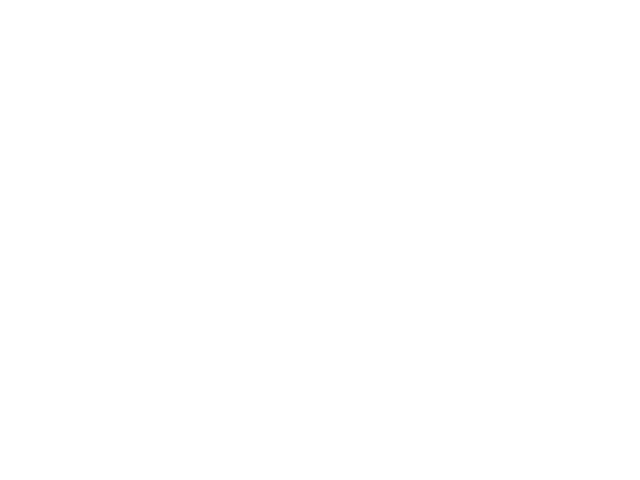

In [8]:
fig1 = plt.figure()

In [9]:
y_min, y_max = np.min(y_array), np.max(y_array)
ax1 = plt.axes()
plt.axis([x_min-0.1, x_max+0.1, y_min-0.1, y_max+0.1]);

In [10]:
line1, = ax1.plot([],[],'b') 
print(type(line1))
line1.get_xdata(), line1.get_ydata()

<class 'matplotlib.lines.Line2D'>


(array([], dtype=float64), array([], dtype=float64))

In [11]:
?line1.get_xdata

Signature: line1.get_xdata(orig=True)
Docstring:
Return the xdata.

If *orig* is *True*, return the original data, else the
processed data.
File:      ~/labs/.venv/lib/python3.12/site-packages/matplotlib/lines.py
Type:      method

In [12]:
def at_frame1(point):
 """добавляет к объекту line1 точку с координатами (point[0],point[1])

 Arguments :

 point : массив из двух элементов

 Returns : None
 """
 x_coord = list(line1.get_xdata())
 y_coord = list(line1.get_ydata())

 x_coord.append(point[0])
 y_coord.append(point[1])

 line1.set_data(x_coord, y_coord) 

In [13]:
?line1.set_data

Signature: line1.set_data(*args)
Docstring:
Set the x and y data.

Parameters
----------
*args : (2, N) array or two 1D arrays

See Also
--------
set_xdata
set_ydata
File:      ~/labs/.venv/lib/python3.12/site-packages/matplotlib/lines.py
Type:      method

In [14]:
help(at_frame1)

Help on function at_frame1 in module __main__:

at_frame1(point)
    добавляет к объекту line1 точку с координатами (point[0],point[1])

    Arguments :

    point : массив из двух элементов

    Returns : None



In [15]:
?at_frame1

Signature: at_frame1(point)
Docstring:
добавляет к объекту line1 точку с координатами (point[0],point[1])

Arguments :

point : массив из двух элементов

Returns : None
File:      /tmp/ipykernel_58562/1118907211.py
Type:      function

In [16]:
print(at_frame1.__doc__)

добавляет к объекту line1 точку с координатами (point[0],point[1])

 Arguments :

 point : массив из двух элементов

 Returns : None
 


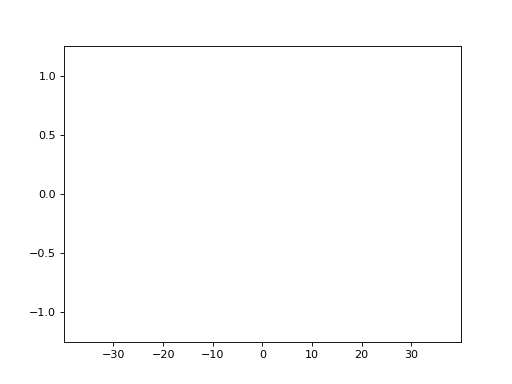

In [34]:
fig1 = plt.figure()
ax1 = plt.axes()
plt.axis([x_min-0.1, x_max+0.1, y_min-0.1, y_max+0.1])
line1, = ax1.plot([], [],'b')
FuncAnimation(fig1, at_frame1, frames=matrix, repeat=False, interval=15)

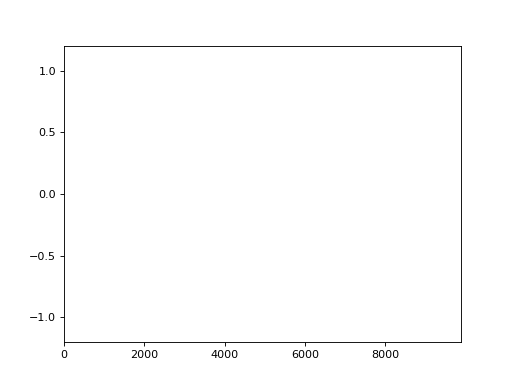

In [32]:

tmin = 0.0
tmax = 2*np.pi
step = (tmax - tmin) / 100.0
t_array = np.arange(tmin, tmax + step, step)

# Параметрическая функция
def x_t(t): return (3*t**2 + 1)/3*t**3   
def y_t(t): return np.sin((t**3)/3 + t)   

x_array = x_t(t_array)
y_array = y_t(t_array)
points = np.column_stack((x_array, y_array))

# Фигура
fig2 = plt.figure()
ax2 = plt.axes()
ax2.set_xlim(np.min(x_array)-0.2, np.max(x_array)+0.2)
ax2.set_ylim(np.min(y_array)-0.2, np.max(y_array)+0.2)
line2, = ax2.plot([], [], 'r-')

def at_frame2(pt):
    xs = list(line2.get_xdata())
    ys = list(line2.get_ydata())
    xs.append(pt[0]); ys.append(pt[1])
    line2.set_data(xs, ys)
    return line2,

anim2 = FuncAnimation(
    fig2,
    at_frame2,
    frames=points,
    repeat=False,
    interval=15,
    blit=True
)

plt.show()

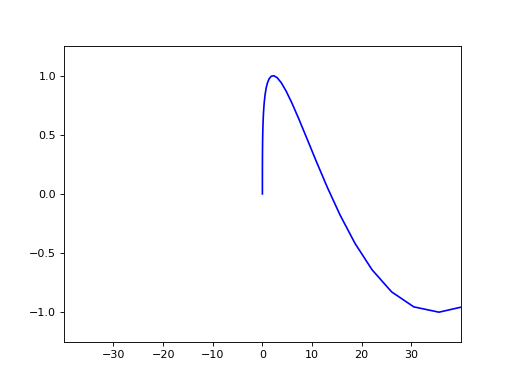

In [31]:
fig2 = plt.figure()
ax2 = plt.axes()
plt.axis([x_min-0.1, x_max+0.1, y_min-0.1, y_max+0.1])
line1, = ax2.plot(x_array, y_array,'b') 
line2, = ax2.plot([], [],'go') 

In [20]:
def at_frame2(point):
 """задает объект line2 точкой с координатами (point[0],point[1])

 Arguments :

 point : массив из двух элементов

 Returns : None
 """
 line2.set_data([point[0]],[point[1]])

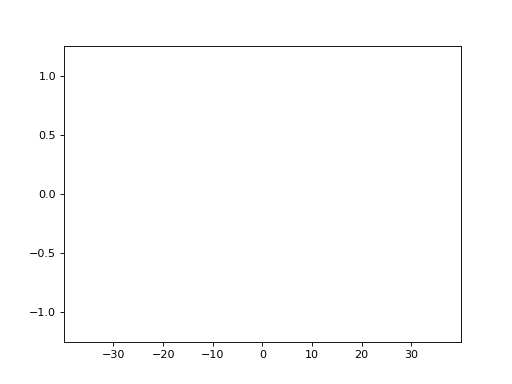

In [30]:
fig2 = plt.figure()
ax2 = plt.axes()
plt.axis([x_min-0.1, x_max+0.1, y_min-0.1, y_max+0.1])
def init():
 """создает начальное состояние графической области"""
 global line2
 line1, = ax2.plot(x_array, y_array,'b')
 line2, = ax2.plot([], [],'go')
 plt.legend([r'$y(x) = \sin^5(x)$', 'Movable point'])
FuncAnimation(fig2, at_frame2, frames=matrix, init_func=init, repeat=False, interval=20)

In [22]:
plt.close('all')

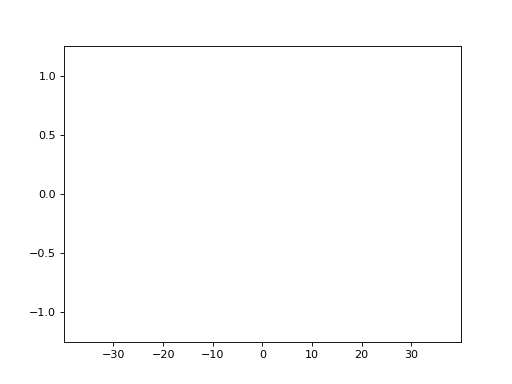

In [29]:
fig3 = plt.figure()
ax3 = plt.axes()
plt.axis([x_min-0.1, x_max+0.1, y_min-0.1, y_max+0.1])
def init():
 
 global point_B, secant_line 

 curve, = ax3.plot(x_array, y_array,'b') 

 A = np.array([x_array[0], y_array[0]])
 point_A, = ax3.plot(A[0],A[1],'ro') 

 B = np.array([x_array[-1], y_array[-1]])
 point_B, = ax3.plot(B[0],B[1],'go') 

 secant_p = [A + (B - A)*t for t in [-2, 2]] 
 secant_p = np.array(secant_p)
 secant_line, = ax3.plot(secant_p[:,0], secant_p[:,1],'g') 

 plt.legend([r'$y(x) = \sin(x)^5$','Unmovable point A','Мovable point B','Secant line'])
def at_frame3(point):
 """do ...

 Arguments :

 point : массив из двух элементов, задающий координаты подвижной точки

 Returns : None
 """
 ...

FuncAnimation(fig3, at_frame3, frames=matrix[::-1],
 init_func=init, repeat=False, interval=20) 

In [24]:
plt.close('all')

In [25]:

import sympy as sp
from matplotlib.lines import Line2D

def at_frame3(point):
    
    
    EPS = 1e-9
    
    x_moving, y_moving = point[0], point[1]
    
    x_fixed, y_fixed = fixed_point[0], fixed_point[1]
    
    distance = np.sqrt((x_moving - x_fixed)**2 + (y_moving - y_fixed)**2)
    
    moving_point.set_data([x_moving], [y_moving])
    
    if distance > EPS:
        
        x_range = ax.get_xlim()
        y_range = ax.get_ylim()
        
        dx = x_moving - x_fixed
        dy = y_moving - y_fixed
        
        if abs(dx) > EPS:
            t1 = (x_range[0] - x_fixed) / dx
            t2 = (x_range[1] - x_fixed) / dx
        elif abs(dy) > EPS:
            t1 = (y_range[0] - y_fixed) / dy
            t2 = (y_range[1] - y_fixed) / dy
        else:
            t1, t2 = -10, 10
        
        t_min, t_max = min(t1, t2), max(t1, t2)
        
        t_line = np.linspace(t_min, t_max, 100)
        x_line = x_fixed + dx * t_line
        y_line = y_fixed + dy * t_line
        
        line_secant.set_data(x_line, y_line)
        
    else:
        
        
        eq1 = sp.Eq(x_expr, x_moving)
        eq2 = sp.Eq(y_expr, y_moving)
        
        
        try:
            f = sp.lambdify(t_param, (x_expr - x_moving)**2 + (y_expr - y_moving)**2, 'numpy')
            t_guess = np.linspace(0, 2*np.pi, 1000)
            f_values = f(t_guess)
            t_current = t_guess[np.argmin(f_values)]
        except:
            t_current = 0
        
        dx_dt = sp.diff(x_expr, t_param)
        dy_dt = sp.diff(y_expr, t_param)
        
        dx_func = sp.lambdify(t_param, dx_dt, 'numpy')
        dy_func = sp.lambdify(t_param, dy_dt, 'numpy')
        
        dx = dx_func(t_current)
        dy = dy_func(t_current)
        
        length = np.sqrt(dx**2 + dy**2)
        if length > EPS:
            dx /= length
            dy /= length
        
        x_range = ax.get_xlim()
        y_range = ax.get_ylim()
        
        if abs(dx) > EPS:
            t1 = (x_range[0] - x_moving) / dx
            t2 = (x_range[1] - x_moving) / dx
        elif abs(dy) > EPS:
            t1 = (y_range[0] - y_moving) / dy
            t2 = (y_range[1] - y_moving) / dy
        else:
            t1, t2 = -10, 10
        
        t_min, t_max = min(t1, t2), max(t1, t2)
        
        t_line = np.linspace(t_min, t_max, 100)
        x_line = x_moving + dx * t_line
        y_line = y_moving + dy * t_line
        
        line_secant.set_data(x_line, y_line)
    
    return line_secant, moving_point

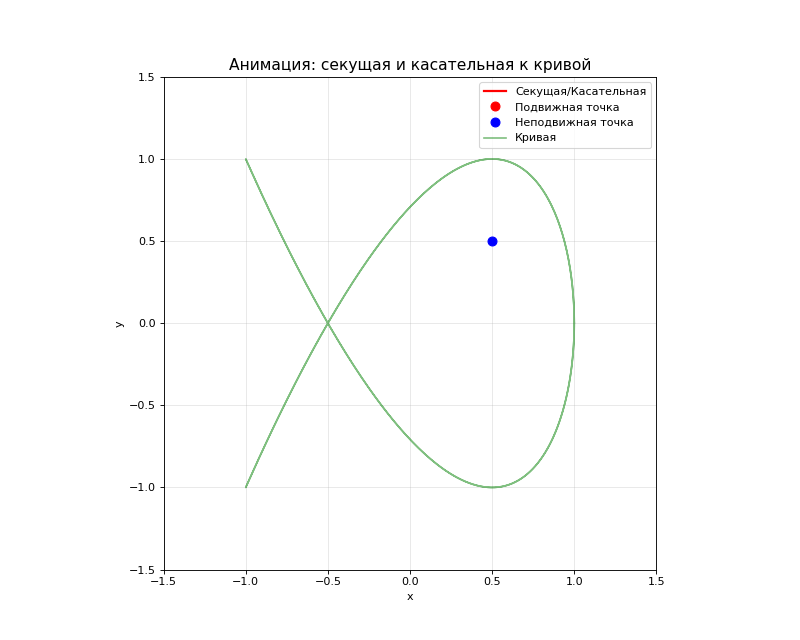

In [28]:


t_param = sp.Symbol('t')
x_expr = sp.cos(2*t_param)
y_expr = sp.sin(3*t_param)

fixed_point = [0.5, 0.5]

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title('Анимация: секущая и касательная к кривой', fontsize=14)
ax.set_xlabel('x')
ax.set_ylabel('y')

line_secant, = ax.plot([], [], 'r-', linewidth=2, label='Секущая/Касательная')
moving_point, = ax.plot([], [], 'ro', markersize=8, label='Подвижная точка')
fixed_point_marker, = ax.plot([fixed_point[0]], [fixed_point[1]], 'bo', 
                               markersize=8, label='Неподвижная точка')

t_curve = np.linspace(0, 2*np.pi, 1000)
x_curve = np.cos(2*t_curve)
y_curve = np.sin(3*t_curve)
ax.plot(x_curve, y_curve, 'g-', alpha=0.5, label='Кривая')

ax.legend(loc='upper right')

t_values = np.linspace(0, 2*np.pi, 200)
points = np.column_stack((np.cos(2*t_values), np.sin(3*t_values)))

anim = FuncAnimation(fig, at_frame3, frames=points, interval=50, blit=True)

plt.show()

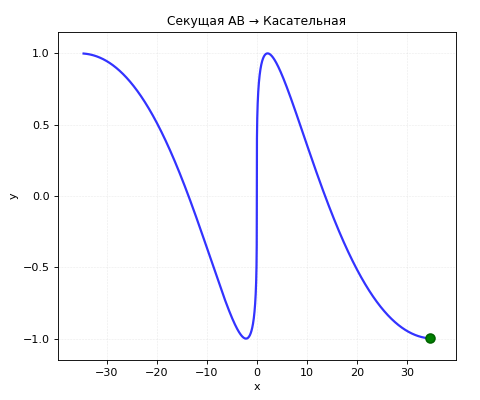

In [27]:

def x_t(t):
    return (3*t**2 + 1)/3 * t**3

def y_t(t):
    return np.sin((t**3)/3 + t)

t_sym = sp.Symbol('t')
x_sym = (3*t_sym**2 + 1)/3 * t_sym**3
y_sym = sp.sin((t_sym**3)/3 + t_sym)

dx_dt_sym = sp.diff(x_sym, t_sym)
dy_dt_sym = sp.diff(y_sym, t_sym)

dx_dt_func = sp.lambdify(t_sym, dx_dt_sym, 'numpy')
dy_dt_func = sp.lambdify(t_sym, dy_dt_sym, 'numpy')

tmin = -2.0
tmax = 2.0

x_A = x_t(tmin)
y_A = y_t(tmin)

x_B = x_t(tmax)
y_B = y_t(tmax)

n_frames = 1000
t_values = np.linspace(tmin, tmax, n_frames)
x_moving = x_t(t_values)
y_moving = y_t(t_values)

t_curve = np.linspace(tmin, tmax, 5000)
x_curve = x_t(t_curve)
y_curve = y_t(t_curve)

def get_line_through_points(x1, y1, x2, y2, ax):
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    dx = x2 - x1
    dy = y2 - y1
    
    if abs(dx) < 1e-9 and abs(dy) < 1e-9:
        return None, None
    
    if abs(dx) > 1e-9:
        t_left = (xlim[0] - x1) / dx
        t_right = (xlim[1] - x1) / dx
        t_min = min(t_left, t_right)
        t_max = max(t_left, t_right)
    else:
        if abs(dy) > 1e-9:
            t_bottom = (ylim[0] - y1) / dy
            t_top = (ylim[1] - y1) / dy
            t_min = min(t_bottom, t_top)
            t_max = max(t_bottom, t_top)
        else:
            t_min, t_max = -10, 10
    
    t_line = np.linspace(t_min, t_max, 300)
    x_line = x1 + dx * t_line
    y_line = y1 + dy * t_line
    
    return x_line, y_line

def get_tangent_line_at_point(t0, ax):
    x0 = x_t(t0)
    y0 = y_t(t0)
    
    dx = dx_dt_func(t0)
    dy = dy_dt_func(t0)
    
    length = np.sqrt(dx**2 + dy**2)
    if length > 1e-9:
        dx /= length
        dy /= length
    
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    if abs(dx) > 1e-9:
        t_left = (xlim[0] - x0) / dx
        t_right = (xlim[1] - x0) / dx
        t_min = min(t_left, t_right)
        t_max = max(t_left, t_right)
    elif abs(dy) > 1e-9:
        t_bottom = (ylim[0] - y0) / dy
        t_top = (ylim[1] - y0) / dy
        t_min = min(t_bottom, t_top)
        t_max = max(t_bottom, t_top)
    else:
        t_min, t_max = -10, 10
    
    t_line = np.linspace(t_min, t_max, 300)
    x_line = x0 + dx * t_line
    y_line = y0 + dy * t_line
    
    return x_line, y_line

EPS = 1e-9

def at_frame3(frame_idx):
    x_A = x_moving[frame_idx]
    y_A = y_moving[frame_idx]
    
    x_B = fixed_point[0]
    y_B = fixed_point[1]
    
    moving_point.set_data([x_A], [y_A])
    
    distance = np.sqrt((x_A - x_B)**2 + (y_A - y_B)**2)
    
    if distance < EPS:
        x_line, y_line = get_tangent_line_at_point(tmax, ax)
        if x_line is not None:
            secant_line.set_data(x_line, y_line)
            secant_line.set_color('red')
            secant_line.set_linewidth(3)
    else:
        x_line, y_line = get_line_through_points(x_A, y_A, x_B, y_B, ax)
        if x_line is not None:
            secant_line.set_data(x_line, y_line)
            secant_line.set_color('red')
            secant_line.set_linewidth(2)
    
    return secant_line, moving_point

plt.rcParams['figure.dpi'] = 80
fig, ax = plt.subplots(figsize=(6, 5))

margin_x = 0.15 * max(abs(x_curve.max()), abs(x_curve.min()))
margin_y = 0.15 * max(abs(y_curve.max()), abs(y_curve.min()))

x_min = x_curve.min() - margin_x
x_max = x_curve.max() + margin_x
y_min = y_curve.min() - margin_y
y_max = y_curve.max() + margin_y

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.5)
ax.set_xlabel('x', fontsize=10)
ax.set_ylabel('y', fontsize=10)
ax.set_title('Секущая AB → Касательная', fontsize=11)

ax.plot(x_curve, y_curve, 'b-', linewidth=2, alpha=0.8)

fixed_point = [x_B, y_B]
fixed_marker, = ax.plot([x_B], [y_B], 'go', markersize=8, markeredgecolor='darkgreen', markeredgewidth=1.5)

secant_line, = ax.plot([], [], 'r-', linewidth=2)

moving_point, = ax.plot([], [], 'ro', markersize=7, markeredgecolor='darkred', markeredgewidth=1.5)

plt.subplots_adjust(left=0.12, right=0.95, top=0.92, bottom=0.1)

anim = FuncAnimation(fig, at_frame3, frames=n_frames, interval=12, blit=True, repeat=False)

plt.show()